# Introduction
## Diffusion Equation
The 1D diffusion equation is given by
$$\frac{\partial u(x,t)}{\partial t} = \nu \frac{\partial^2 u(x,t)}{\partial x^2},$$
where
- $u(x,t)$ is the function we're tracking (velocity, temperature, etc)
- $x$ is position
- $t$ is time
- $\nu$ is the diffusion coefficient, ie how fast things spread

## Discretised Laplacian
The central second difference approximation
$$
\frac{d^2u(x_i)}{dx^2}\approx\frac{u_{i+1}-2u_i+u_{i-1}}{h^2}
$$
is used to form the Laplacian matrix
$$
L = \frac{1}{h^2}\begin{pmatrix}
-2 & 1 & 0 & 0 & 1 \\
1 & -2 & 1 & 0 & 0 \\
0 & 1 & -2 & 1 & 0 \\ 
0 & 0 & 1 & -2 & 1 \\
1 & 0 & 0 & 1 & -2
\end{pmatrix}
$$
where we have assumed periodic boundary conditions – setting $u_{-1} = u_N$ and $u_{N+1} = u_0$ – which explains the 1s at the top right and bottom left corners of the matrix.

## Time-Stepping Operator
The time-stepping operator
$$
A = \mathbb I + \nu dt \  L
$$
is the operator that carries out the time evolution in steps using the Forward Euler scheme.

## Time Evolution using Tensor Networks
In the dense case, the state vector is updated by repeatedly applying the time-step operator
$$
\mathbf u(t_{i+1})=A  \mathbf u(t_i).
$$

In the tensor network formulation, $A$ and $\mathbf u(t_0)$ are converted into an MPO and an MPS respectively. The same update rule is performed in the tensor network language, which is to contract the MPO with the MPS to obtain the next update.

After each update, the resulting MPS is compressed via SVD truncation to limit bond dimension.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import time

# Parameters

In [3]:
n = 6                   # you will have a 1D line of 2^n points, and the MPSs/MPOs will have n sites.
nu = 1e-3               # diffusion coefficient 
steps = 2000           # number of steps required for time evolution
save_every = 200         # after this many steps, take a snapshot of the function to plot on the graph
cfl = 0.1                # controls time step relative to grid spacing. affects stability of time0-step scheme

u0_type = "quadratic"      # "sines" | "quadratic" | "random"

In [4]:
# TN-specific parameters

# parameters for forming the initial MPS
init_cutoff = 1e-12
init_max_bond = 64

# parameters for forming the initial MPO
mpo_cutoff = 1e-12
mpo_max_bond = 256

# SVD truncation and bond dimension limits during contractions
tn_cutoff = 1e-10
tn_max_bond = 64

# Problem Setup

In [5]:
# ============
# DENSE SOLVER
# ============

def laplacian_1d(N, dx): 
    L = np.zeros((N, N))
    for i in range(N):
        L[i, i] = -2.0
        L[i, (i - 1) % N] = 1.0
        L[i, (i + 1) % N] = 1.0
    return L / (dx * dx)

def evolve_dense(u0, steps, A, save_every=50):
    t0 = time.perf_counter()

    u = u0.copy()

    saved = []
    times = []
    norms = []

    t = 0.0
    
    for i in range(steps):
        # save current state
        if i % save_every == 0:
            saved.append(u.copy())
            times.append(t)
            norms.append(np.linalg.norm(u))
    
        # advance one timestep
        u = A @ u
        t += dt
    
    # save final state
    saved.append(u.copy())
    times.append(t)
    norms.append(np.linalg.norm(u))

    elapsed = time.perf_counter() - t0
    
    return np.array(times), np.array(saved), np.array(norms), elapsed



# ==================
# MPS/MPO GENERATION
# ==================

# these helper functions convert from vectors to MPS and vice versa,
# as well as from matrices to MPOs

def vec_to_qtt_mps(u, n, cutoff=1e-10, max_bond=64):
    T = u.reshape((2,) * n)
    mps = qtn.MatrixProductState.from_dense(T, cutoff=cutoff, max_bond=max_bond)
    return mps

def qtt_mps_to_vec(mps):
    T = mps.to_dense()
    return np.asarray(T).reshape(-1)

def mat_to_qtt_mpo(A, n, cutoff=1e-12, max_bond=256):
    return qtn.MatrixProductOperator.from_dense(
        A, dims=[2] * n, cutoff=cutoff, max_bond=max_bond
    )

# measure time taken to construct mps and mpo

def time_mps_construction(u0, n, cutoff, max_bond):
    t0 = time.perf_counter()
    mps0 = vec_to_qtt_mps(u0, n, cutoff, max_bond)
    t1 = time.perf_counter()
    return mps0, t1 - t0

def time_mpo_construction(A, n, cutoff, max_bond):
    t0 = time.perf_counter()
    mpoA = mat_to_qtt_mpo(A, n, cutoff, max_bond)
    t1 = time.perf_counter()
    return mpoA, t1 - t0


# ====================
# TIME EVOLUTION IN TN
# ====================

def step_mps(mps, mpo, cutoff=1e-10, max_bond=64):
    mps_new = mpo.apply(mps)
    mps_new.compress(cutoff=cutoff, max_bond=max_bond)
    return mps_new

def evolve_mps(mps0, mpoA, steps, save_every=50, cutoff=1e-10, max_bond=64):
    mps = mps0.copy()
    saved = []
    bonds = []
    
    for i in range(steps):
        if i % save_every == 0:
            saved.append(mps.copy())
            bonds.append(max(mps.bond_sizes()))
    
        mps = step_mps(mps, mpoA, cutoff, max_bond)
    
    # save final state
    saved.append(mps.copy())
    bonds.append(max(mps.bond_sizes()))
    return saved, bonds

# Experiment

Time taken: 0.00677391595672816


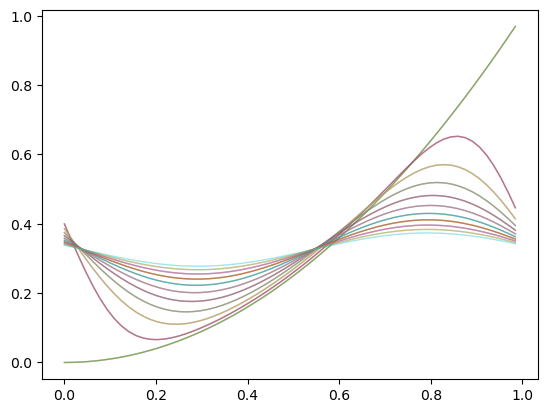

In [6]:
# ====================
# EXECUTE DENSE SOLVER
# ====================

N = 2**n
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0] # corresponds to h in mathematical notation

dt = cfl * dx*dx / nu 

if u0_type == "sines":
    u0 = np.sin(2*np.pi*2*x) + 0.5*np.sin(2*np.pi*7*x)
elif u0_type == "quadratic":
    u0 = x**2
elif u0_type == "random":
    u0 = np.random.randn(N)
else:
    u0 = np.asarray(u0_type)

L = laplacian_1d(N, dx)                             
A = np.eye(N) + dt * nu * L                                        
times, us, norms, time_taken = evolve_dense(u0, steps, A, save_every)             

ks = np.linspace(0, len(times)-1, 30, dtype=int)

for k in ks:
    plt.plot(x, us[k], alpha=0.4, linewidth=1)

print("Time taken:", time_taken)

MPS construction: 0.013105624995660037 s
MPO construction: 0.0005952080246061087 s


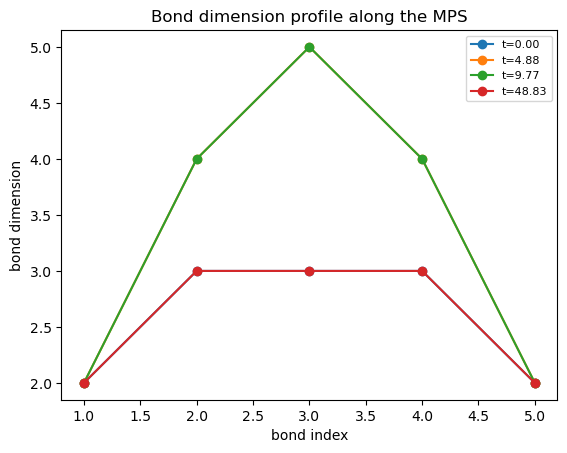

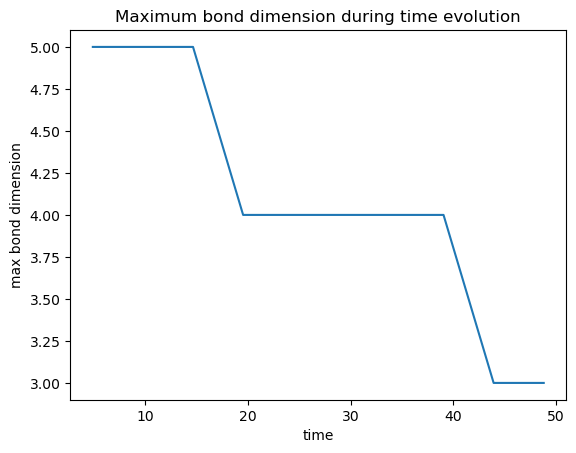

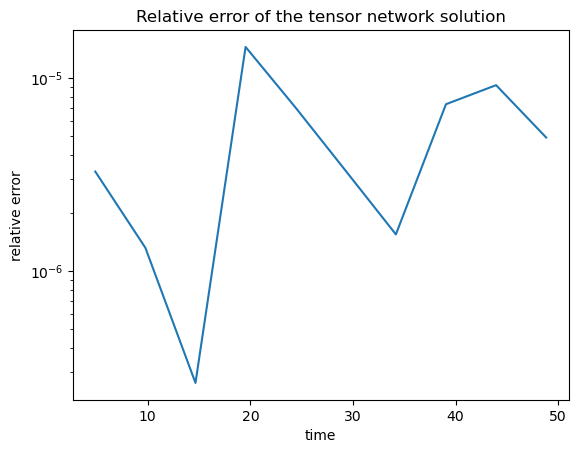

In [7]:
# =================
# EXECUTE TN SOLVER
# =================


mps0, t_mps = time_mps_construction(u0, n, init_cutoff, init_max_bond)
mpoA, t_mpo = time_mpo_construction(A, n, mpo_cutoff, mpo_max_bond)

print("MPS construction:", t_mps, "s")
print("MPO construction:", t_mpo, "s")

mps_saved, bond_track = evolve_mps(
    mps0,
    mpoA,
    steps,
    save_every,
    tn_cutoff,
    tn_max_bond
)

errs = []
for i, mps in enumerate(mps_saved):
    u_tn = qtt_mps_to_vec(mps)
    u_dense = us[i]
    err = np.linalg.norm(u_tn - u_dense) / np.linalg.norm(u_dense)
    errs.append(err)

ks = [0, len(times)//8, len(times)//4, -1]

for k in ks:
    bd = mps_saved[k].bond_sizes()
    plt.plot(range(1, len(bd)+1), bd, marker="o", label=f"t={times[k]:.2f}")
plt.xlabel("bond index")
plt.ylabel("bond dimension")
plt.title("Bond dimension profile along the MPS")
plt.legend(fontsize=8)

plt.show()


plt.plot(times[1:], bond_track[1:])
plt.xlabel("time")
plt.ylabel("max bond dimension")
plt.title("Maximum bond dimension during time evolution")
plt.show()


plt.plot(times[1:], errs[1:])
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("relative error")
plt.title("Relative error of the tensor network solution")
plt.show()